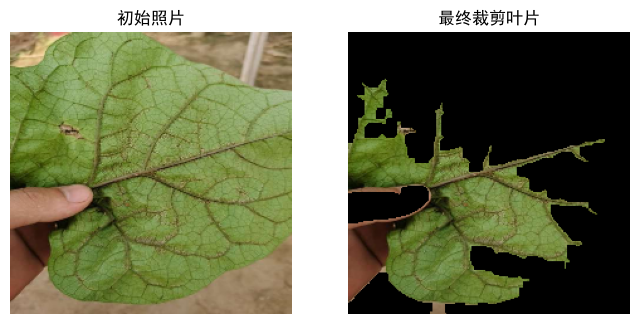

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

plt.rcParams["font.family"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False

real_leaf001=cv2.imread("leaf001.jpg")
real_leaf001_rgb=cv2.cvtColor(real_leaf001,cv2.COLOR_BGR2RGB)
real_leaf001_rgb_224=cv2.resize(real_leaf001_rgb,(224,224))
gray_leaf001_224=cv2.cvtColor(real_leaf001_rgb_224,cv2.COLOR_RGB2GRAY)
blur_leaf001=cv2.GaussianBlur(gray_leaf001_224,(7,7),0)
ret,mask=cv2.threshold(blur_leaf001,thresh=0,maxval=255,type=cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

kernel=np.ones((7,7),np.uint8)
mask=cv2.morphologyEx(mask,cv2.MORPH_CLOSE,kernel)

contour,hierarchy=cv2.findContours(mask,mode=cv2.RETR_EXTERNAL,method=cv2.CHAIN_APPROX_SIMPLE)

# 过滤掉面积小于全图5%的小轮廓（手指、碎叶脉）
img_area = 224*224 # 整张图的面积
valid_contours = [c for c in contour if cv2.contourArea(c) > 0.05*img_area]
# 从过滤完的大轮廓里，取面积最大的那个当叶片
leaf_contour = sorted(valid_contours, key=cv2.contourArea, reverse=True)[0]


leaf_contour=sorted(contour,key=cv2.contourArea,reverse=True)[0]

leaf_mask=np.zeros_like(gray_leaf001_224)
cv2.drawContours(leaf_mask,[leaf_contour],contourIdx=-1,color=255,thickness=-1)
leaf_mask_rgb=cv2.cvtColor(leaf_mask,cv2.COLOR_GRAY2RGB)
leaf_only=(real_leaf001_rgb_224*(leaf_mask_rgb/255)).astype(np.uint8)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(real_leaf001_rgb_224)
plt.title("初始照片")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(leaf_only)
plt.title("最终裁剪叶片")
plt.axis('off')
plt.show()